# Autoencoder for Image Reconstruction

This notebook implements and trains a simple **convolutional autoencoder** on grayscale images. The goal is to compress images into a **low-dimensional latent vector** and then reconstruct them back. This is useful for **dimensionality reduction, denoising, and feature learning**.

---

## Design Choices

### 1. Encoder
- Uses **convolutions (`Conv2d`) + ReLU** to progressively extract features.  
- Ends with a **flattening layer** to turn the 4D feature map into a 2D tensor: Input shape: (B, C, H, W) → Flattened: (B, C × H × W)
- A **fully connected layer** reduces this to a fixed latent vector of size `LATENT_DIMS`.

### 2. Decoder
- Starts with a **linear layer** that expands the latent vector back to a feature map.  
- Uses **transpose convolutions (`ConvTranspose2d`) + ReLU** to "upscale" and reconstruct spatial structure.  
- Ends with a **`Tanh` activation** so outputs lie in **[-1, 1]**, matching the normalized input images.
---

## Training Loop

1. **Forward pass**: input → encoder → decoder → reconstruction.  
2. **Loss**: Mean Squared Error (MSE) between reconstruction and original input.  
3. **Backward pass**: gradients flow from loss to update both encoder and decoder.  
4. **Optimization**: Adam optimizer with learning rate `LR`.
---

## Evaluation & Visualization
- **Original vs Reconstructed Images**: plotted side by side for visual inspection.  
- **Compression Rate**: calculated as the percentage reduction from raw pixels to latent dimensions.  

---


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

DATA_PATH = "data/train"
BATCH_SIZE = 32
LATENT_DIMS = 128
NUM_EPOCHS = 100
LR = 1e-3
IMG_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


In [6]:
transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                transforms.Grayscale(num_output_channels=1),
                                transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5))
                                ])

dataset = ImageFolder(root=DATA_PATH, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

class Encoder(nn.Module):
    def __init__(self, latent_dims: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ReLU(),
        )
        self.flatten = nn.Flatten()  # Reshapes from (batch, channels, height, width) → (batch, channels*height*width)
        self.fc = nn.Linear(128*8*8, latent_dims)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        return self.fc(x)
    
class Decoder(nn.Module):
    def __init__(self, latent_dims: int):
        super().__init__()
        self.fc = nn.Linear(latent_dims, 128*8*8)

        """
        We normalized the raw pixel values to [-1, 1] with transforms.Normalize((0.5,), (0.5,)) so we need to be
        able to reconstruct them with the same scale. We use tanh activation function here to output values in [-1, 1].
        """
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 128, 8, 8) # Reshapes the flat tensor back into 4D. The -1 lets PyTorch infer the batch size automatically.
        return self.deconv(x)
    

class Autoencoder(nn.Module):
    def __init__(self, latent_dims: int):
        super().__init__()
        self.encoder = Encoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [12]:
# Training
model = Autoencoder(LATENT_DIMS).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for data, _ in dataloader:
        data = data.to(DEVICE)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, data)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data.size(0)

    epoch_loss = running_loss / len(dataset)
    losses.append(epoch_loss)
    print(f"Epoch {epoch} Loss: {epoch_loss:.4f}")

Epoch 0 Loss: 0.3822
Epoch 1 Loss: 0.2232
Epoch 2 Loss: 0.1960
Epoch 3 Loss: 0.1807
Epoch 4 Loss: 0.1698
Epoch 5 Loss: 0.1555
Epoch 6 Loss: 0.1221
Epoch 7 Loss: 0.1031
Epoch 8 Loss: 0.0903
Epoch 9 Loss: 0.0835
Epoch 10 Loss: 0.0781
Epoch 11 Loss: 0.0726
Epoch 12 Loss: 0.0687
Epoch 13 Loss: 0.0650
Epoch 14 Loss: 0.0625
Epoch 15 Loss: 0.0601
Epoch 16 Loss: 0.0571
Epoch 17 Loss: 0.0547
Epoch 18 Loss: 0.0524
Epoch 19 Loss: 0.0508
Epoch 20 Loss: 0.0486
Epoch 21 Loss: 0.0469
Epoch 22 Loss: 0.0449
Epoch 23 Loss: 0.0438
Epoch 24 Loss: 0.0419
Epoch 25 Loss: 0.0402
Epoch 26 Loss: 0.0384
Epoch 27 Loss: 0.0373
Epoch 28 Loss: 0.0357
Epoch 29 Loss: 0.0341
Epoch 30 Loss: 0.0325
Epoch 31 Loss: 0.0310
Epoch 32 Loss: 0.0298
Epoch 33 Loss: 0.0286
Epoch 34 Loss: 0.0275
Epoch 35 Loss: 0.0268
Epoch 36 Loss: 0.0263
Epoch 37 Loss: 0.0259
Epoch 38 Loss: 0.0243
Epoch 39 Loss: 0.0248
Epoch 40 Loss: 0.0249
Epoch 41 Loss: 0.0253
Epoch 42 Loss: 0.0240
Epoch 43 Loss: 0.0218
Epoch 44 Loss: 0.0207
Epoch 45 Loss: 0.019

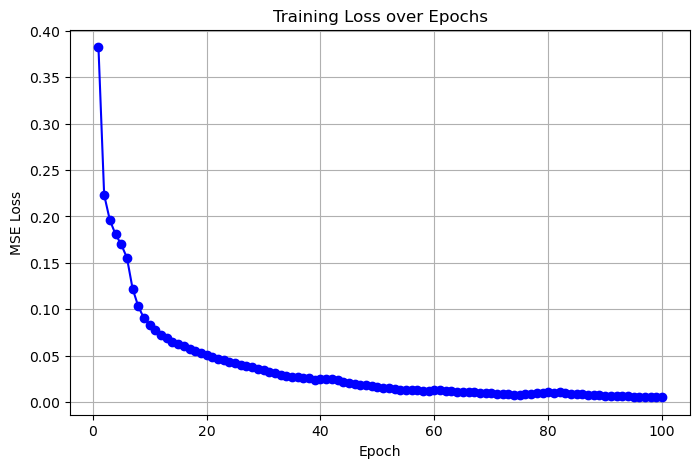

In [13]:
# Plot losses
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), losses, marker='o', color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


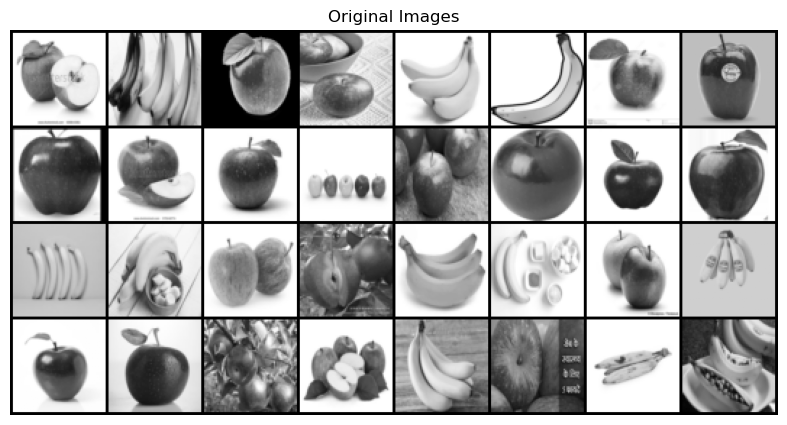

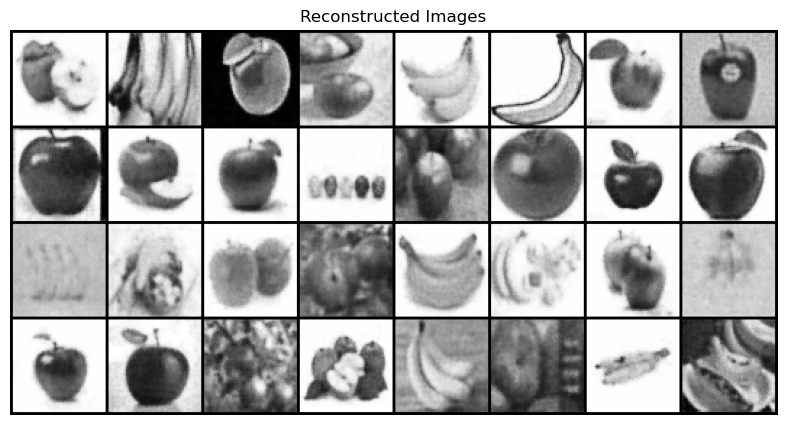

Compression rate: 96.88%


In [14]:
def show_images(imgs, title=""):
    imgs = imgs * 0.5 + 0.5  # denormalize
    imgs = imgs.clamp(0, 1)
    grid = vutils.make_grid(imgs, nrow=8)
    plt.figure(figsize=(10, 5))
    plt.axis("off")
    plt.title(title)
    plt.imshow(np.transpose(grid.cpu().numpy(), (1, 2, 0)))
    plt.show()

images, _ = next(iter(dataloader))
images = images.to(DEVICE)

with torch.no_grad():
    recon = model(images)

show_images(images, "Original Images")
show_images(recon, "Reconstructed Images")

image_size = IMG_SIZE * IMG_SIZE
compression_rate = (1 - LATENT_DIMS / image_size) * 100
print(f"Compression rate: {compression_rate:.2f}%")